## 1. Import Library

In [2]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Warning
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

#Tuning
import optuna

from sklearn.model_selection import cross_val_score

import joblib

## 2. Load Dataset

Tahap pertama adalah memuat dataset dan melihat struktur awal data sebelum dilakukan analisis lebih lanjut.

In [3]:
df = pd.read_csv("../data/weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 145460
Jumlah Kolom : 23


## 3. Data Inspection

Tahap ini bertujuan memahami karakteristik dataset, seperti tipe data, missing values, duplicate data, dan distribusi target.

In [5]:
print('============Informasi Dataset============\n')
df.info()

============Informasi Dataset============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null 

In [6]:
print('============Informasi Statistik============\n')
df.describe().T

============Informasi Statistik============



,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


In [7]:
print('======Informasi Missing Value======\n')
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Persentase": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    by="Persentase",
    ascending=False
).head(15)

======Informasi Missing Value======



,Missing,Persentase
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


In [8]:
print('============Informasi Duplikat============\n')
print("Duplicate :",df.duplicated().sum())

============Informasi Duplikat============

Duplicate : 0


In [9]:
print('============Target Distribusi============\n')
df["RainTomorrow"].value_counts(dropna=False)

============Target Distribusi============



RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

## 4 Eksploratory Data Analysis

4.1 Distribusi Target

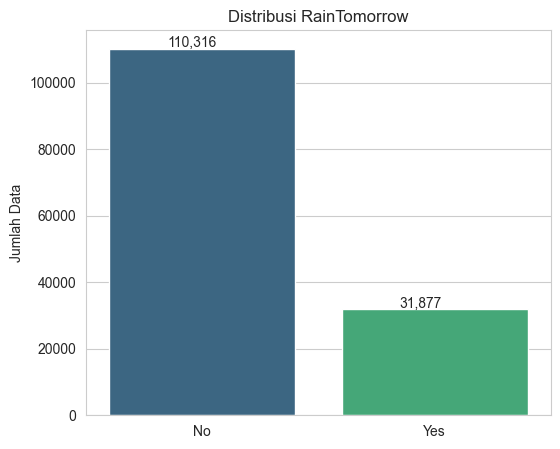

In [10]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="RainTomorrow",
    data=df,
    palette="viridis"
)

plt.title("Distribusi RainTomorrow")
plt.xlabel("")
plt.ylabel("Jumlah Data")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x()+0.25,p.get_height()+500)
    )

plt.show()

> Sebagian besar data berada pada kelas **No**, menunjukkan dataset bersifat tidak seimbang sehingga perlu penanganan class imbalance pada tahap modeling.

4.2 Missing Value

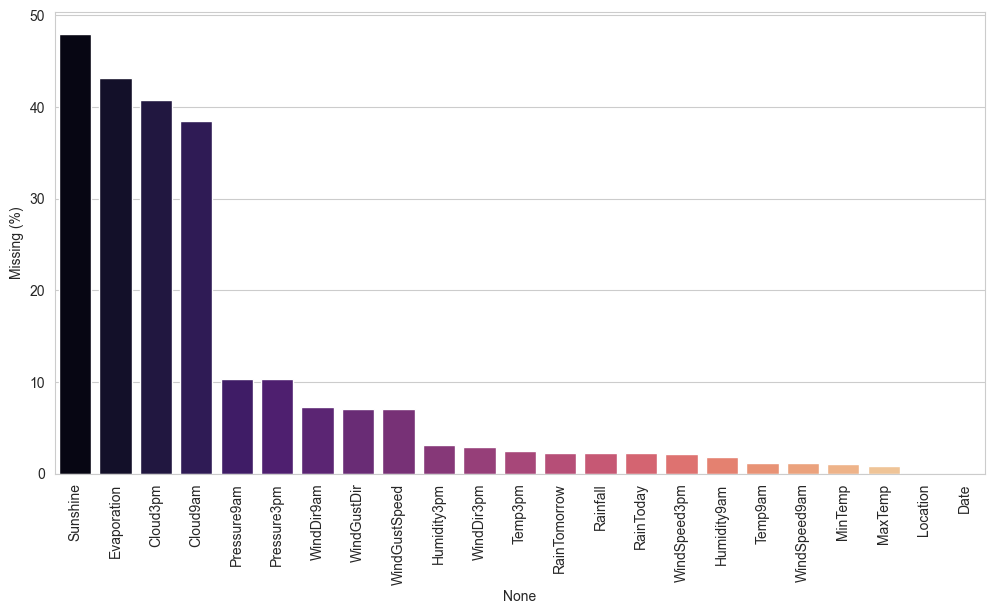

In [11]:
missing = missing.sort_values(
    "Persentase",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.index,
    y=missing["Persentase"],
    palette="magma"
)

plt.xticks(rotation=90)
plt.ylabel("Missing (%)")
plt.show()

> Kolom Sunshine, Evaporation, Cloud9am, dan Cloud3pm memiliki missing value lebih dari 40%, sehingga dipertimbangkan untuk dihapus karena berpotensi menurunkan kualitas model.

4.3 Korelasi

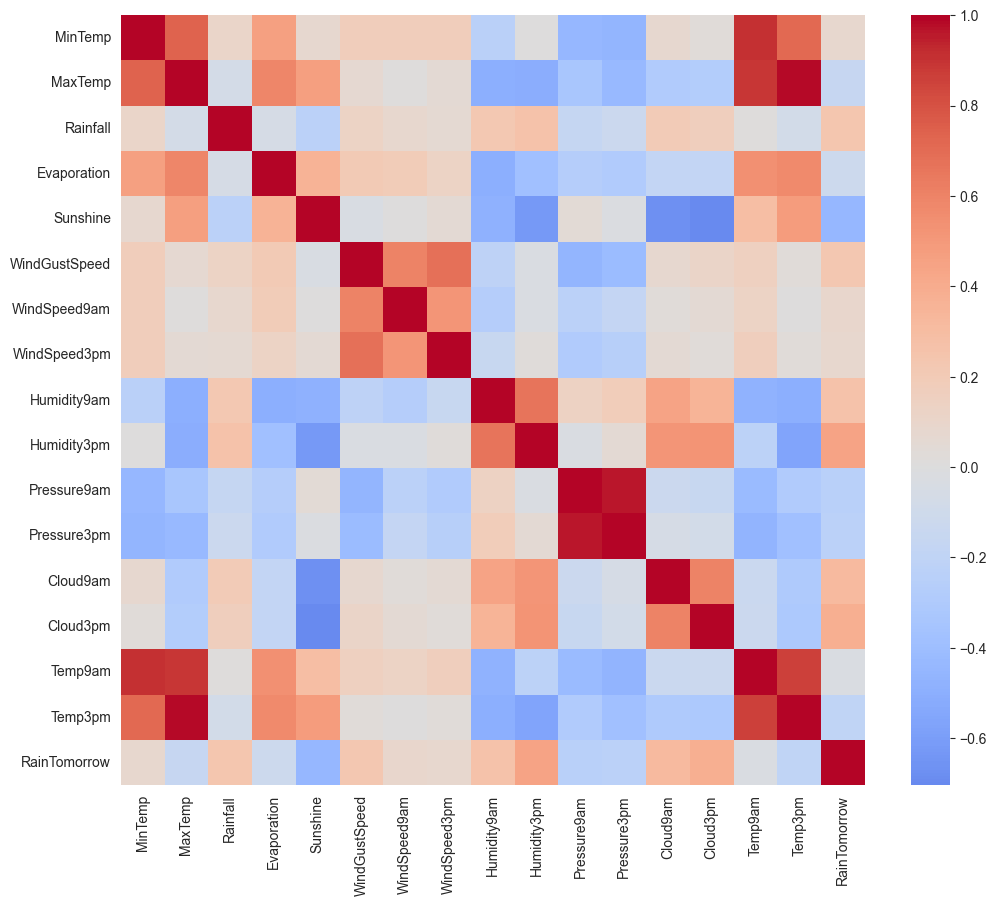

In [12]:
corr_df = df.copy()

corr_df["RainTomorrow"] = corr_df["RainTomorrow"].map({
    "No":0,
    "Yes":1
})

corr = corr_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

4.4 Boxplot Humidity

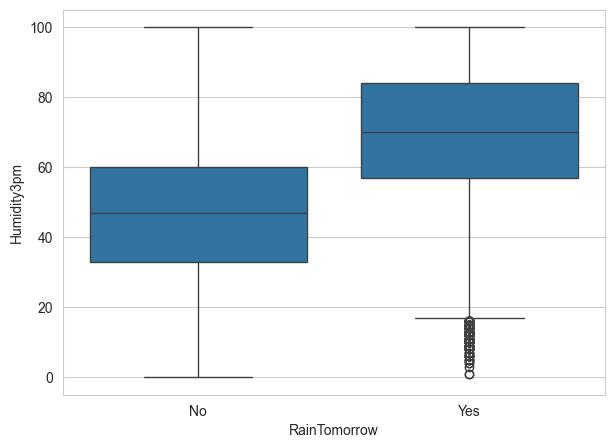

In [13]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="RainTomorrow",
    y="Humidity3pm",
    data=df
)

plt.show()

> Kelembapan pada sore hari cenderung lebih tinggi pada observasi yang diikuti hujan keesokan harinya.

4.5 Rainfall Distribusi

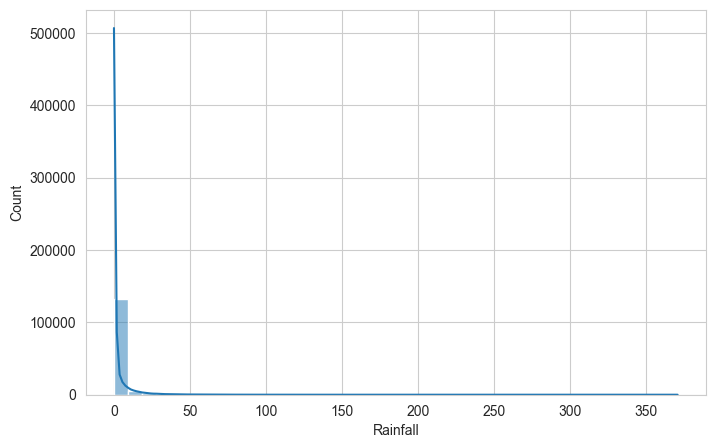

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rainfall"],
    bins=40,
    kde=True
)

plt.show()

## 5. Data Preprocessing

Tahap ini bertujuan menyiapkan dataset agar siap digunakan dalam proses pelatihan model machine learning.

Beberapa langkah preprocessing yang dilakukan meliputi:

- Menghapus kolom dengan missing value yang terlalu tinggi.
- Menghapus data yang tidak memiliki target (`RainTomorrow`).
- Menghapus fitur yang tidak relevan.
- Melakukan feature engineering.
- Memisahkan fitur dan target.
- Membagi data menjadi data training dan testing.
- Melakukan imputasi missing value.
- Melakukan encoding pada fitur kategorikal.
- Menangani class imbalance menggunakan SMOTE.

5.1 Drop Kolom dengan Missing Value Tinggi

In [15]:
# Drop kolom dengan missing value >40%

drop_columns = [
    "Sunshine",
    "Evaporation",
    "Cloud9am",
    "Cloud3pm"
]

df = df.drop(columns=drop_columns)

print(df.shape)

(145460, 19)


5.2 Drop Target yang Missing

In [16]:
df = df.dropna(subset=["RainTomorrow"])

print(df.shape)

(142193, 19)


5.3 Drop Kolom yang Tidak Digunakan

In [17]:
df = df.drop(columns=["Date", "Location"])

df.head()

,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No
1,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No
2,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No
3,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No
4,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No


5.4 Feature Engineering

In [18]:
# Temperature Range 
df["TempRange"] = df["MaxTemp"] - df["MinTemp"]

# Pressure Drop
df["PressureDrop"] = df["Pressure9am"] - df["Pressure3pm"]

# Humidity Rise
df["HumidityRise"] = df["Humidity3pm"] - df["Humidity9am"]

df.head()

,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,TempRange,PressureDrop,HumidityRise
0,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No,9.5,0.6,-49.0
1,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No,17.7,2.8,-19.0
2,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No,12.8,-1.1,-8.0
3,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No,18.8,4.8,-29.0
4,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No,14.8,4.8,-49.0


> Tiga fitur baru ditambahkan berdasarkan pengetahuan domain meteorologi.

- **TempRange** menggambarkan rentang suhu harian yang dapat memengaruhi pembentukan awan.
- **PressureDrop** menunjukkan perubahan tekanan atmosfer, di mana penurunan tekanan sering dikaitkan dengan datangnya hujan.
- **HumidityRise** merepresentasikan peningkatan kelembapan dari pagi ke sore yang berpotensi meningkatkan peluang terjadinya hujan.

5.5 Pisahkan Feature dan Target sekaligus Encode

In [19]:
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

y = y.map({
    "No":0,
    "Yes":1
})

print(X.shape)
print(y.shape)

(142193, 19)
(142193,)


5.6 Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

Training : (113754, 19)
Testing  : (28439, 19)


5.7 Identifikasi Tipe Kolom

In [21]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Numerical :", numerical_features)
print()

print("Categorical :", categorical_features)

Numerical : ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'TempRange', 'PressureDrop', 'HumidityRise']

Categorical : ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


5.8 Preprocessing Pipeline

In [22]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Gabungkan
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

5.9 Fit Transform

In [23]:
# Training
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Testing
X_test_preprocessed = preprocessor.transform(X_test)

# Cek Ukuran
print(X_train_preprocessed.shape)
print(X_test_preprocessed.shape)

(113754, 65)
(28439, 65)


5.10 Handle Class Imbalance

In [24]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_preprocessed,
    y_train
)

In [25]:
# Lihat Distribusi Kelas

print("Sebelum SMOTE")
print(y_train.value_counts())
print()
print("Sesudah SMOTE")
print(y_train_smote.value_counts())

Sebelum SMOTE
RainTomorrow
0    88252
1    25502
Name: count, dtype: int64

Sesudah SMOTE
RainTomorrow
0    88252
1    88252
Name: count, dtype: int64


## 6. Modeling

Pada tahap ini dilakukan pelatihan beberapa model klasifikasi untuk memprediksi apakah akan terjadi hujan pada hari berikutnya.

Model yang dibandingkan meliputi:

- Logistic Regression (Baseline)
- Random Forest
- XGBoost

Setiap model akan dievaluasi menggunakan metrik:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

Karena kasus ini digunakan pada Smart Farming, fokus utama evaluasi adalah **Recall kelas Yes** agar sebanyak mungkin kejadian hujan dapat terdeteksi.

6.1 Fungsi Evaluasi

In [26]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    """
    Menampilkan evaluasi model klasifikasi.
    """

    # Probabilitas kelas positif
    y_prob = model.predict_proba(X_test)[:, 1]

    # Threshold
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")
    print("=" * 60)

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(type(model).__name__)

    plt.show()

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC": roc
    }

6.2 Logistic Regression (Baseline)

In [27]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

Accuracy : 0.7850
Precision: 0.5137
Recall   : 0.7672
F1 Score : 0.6154
ROC AUC  : 0.8584

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.79      0.85     22064
           1       0.51      0.77      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.73     28439
weighted avg       0.83      0.79      0.80     28439



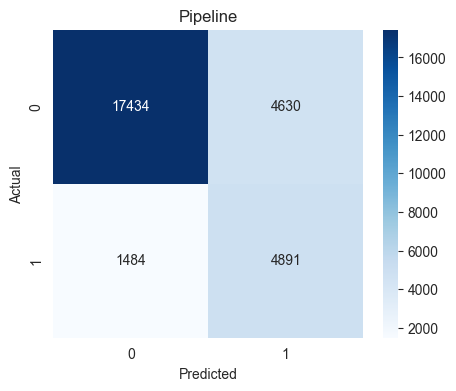

In [28]:
# Training
logistic_pipeline.fit(
    X_train_smote,
    y_train_smote
)

# Evaluasi
logistic_result = evaluate_model(
    logistic_pipeline,
    X_test_preprocessed,
    y_test
)

6.3 Random Forest

In [29]:
RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy : 0.8509
Precision: 0.7109
Recall   : 0.5644
F1 Score : 0.6292
ROC AUC  : 0.8787

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.93      0.91     22064
           1       0.71      0.56      0.63      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.75      0.77     28439
weighted avg       0.84      0.85      0.84     28439



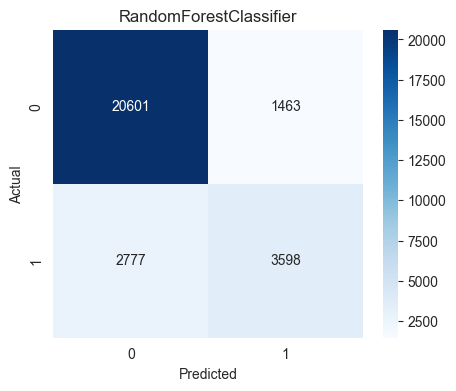

In [30]:
# Training
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Evaluasi
rf_result = evaluate_model(
    rf_model,
    X_test_preprocessed,
    y_test
)

6.4 XGBoost

In [31]:
XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Accuracy : 0.8476
Precision: 0.7401
Recall   : 0.4932
F1 Score : 0.5919
ROC AUC  : 0.8680

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22064
           1       0.74      0.49      0.59      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.72      0.75     28439
weighted avg       0.84      0.85      0.84     28439



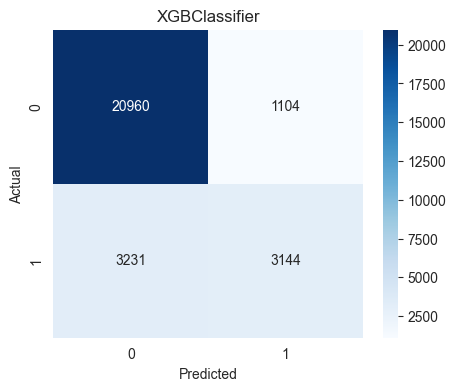

In [32]:
# Training
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# Evaluasi
xgb_result = evaluate_model(
    xgb_model,
    X_test_preprocessed,
    y_test
)

6.5 RandomSearchCV

In [37]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [38]:
best_rf = random_search.best_estimator_

Accuracy : 0.8383
Precision: 0.6445
Recall   : 0.6215
F1 Score : 0.6328
ROC AUC  : 0.8693

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.90      0.90     22064
           1       0.64      0.62      0.63      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.76      0.76     28439
weighted avg       0.84      0.84      0.84     28439



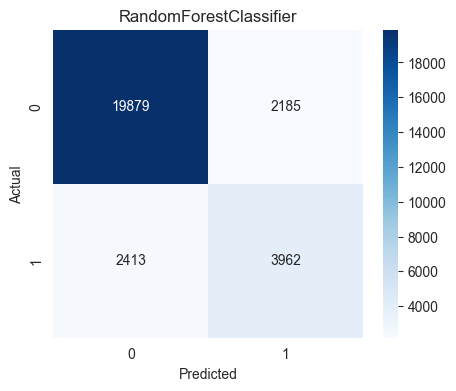

In [39]:
best_rf_result = evaluate_model(
    best_rf,
    X_test_preprocessed,
    y_test
)

## 7. Model Comparison

Seluruh model dibandingkan menggunakan metrik evaluasi yang sama sehingga dapat dipilih model dengan performa terbaik.

Fokus utama pemilihan model adalah Recall pada kelas **RainTomorrow = Yes**, tanpa mengabaikan metrik Accuracy, Precision, F1-Score, dan ROC-AUC.

In [40]:
comparison = pd.DataFrame({
    "Logistic Regression": logistic_result,
    "Random Forest": rf_result,
    "XGBoost": xgb_result,
    "Random Forest Tuned": best_rf_result
}).T

comparison

,Accuracy,Precision,Recall,F1,ROC
Logistic Regression,0.785014,0.513707,0.767216,0.615375,0.858415
Random Forest,0.850909,0.710927,0.564392,0.629241,0.878655
XGBoost,0.847568,0.740113,0.493176,0.591923,0.867977
Random Forest Tuned,0.838321,0.644542,0.621490,0.632806,0.869283


## 8. Feature Importance Analysis

In [54]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
7,num__Humidity3pm,0.154617
2,num__Rainfall,0.108996
12,num__TempRange,0.066820
63,cat__RainToday_No,0.058610
14,num__HumidityRise,0.053887
64,cat__RainToday_Yes,0.053822
6,num__Humidity9am,0.040279
9,num__Pressure3pm,0.038005
3,num__WindGustSpeed,0.037960
8,num__Pressure9am,0.033316


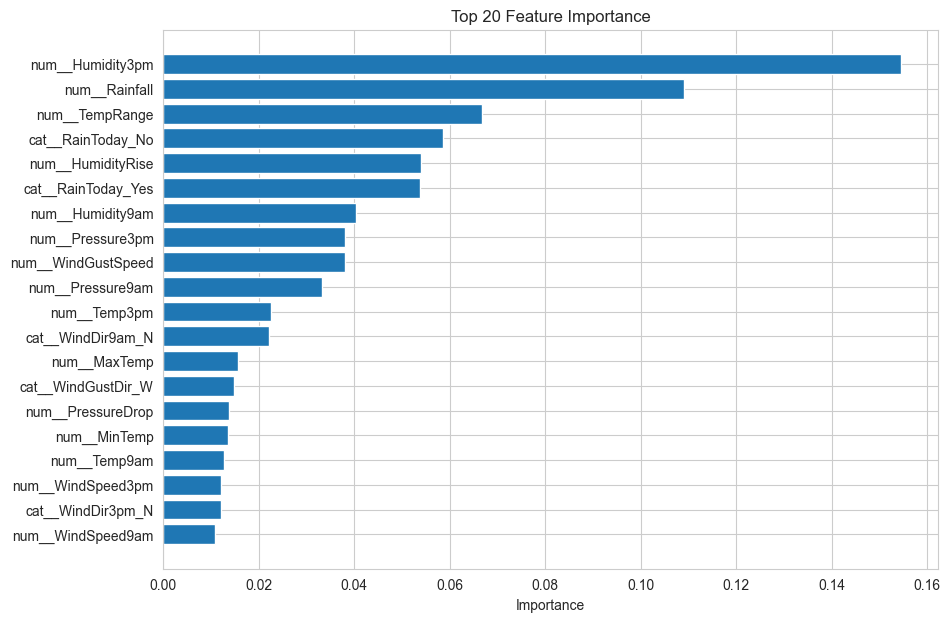

In [55]:
plt.figure(figsize=(10,7))

top_features = importance_df.head(20)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")

plt.show()

## Analisis Feature Importance

Random Forest menghitung tingkat kepentingan setiap fitur berdasarkan kontribusinya dalam proses pembentukan decision tree.

Fitur dengan nilai importance yang sangat kecil kemungkinan hanya memberikan sedikit informasi sehingga dapat dipertimbangkan untuk dihapus guna menyederhanakan model.

## 10. Hapus Fitur yang tidak penting

In [56]:
selected_features = importance_df[
    importance_df["Importance"] >= 0.003
]["Feature"]

selected_features

7         num__Humidity3pm
2            num__Rainfall
12          num__TempRange
63       cat__RainToday_No
14       num__HumidityRise
64      cat__RainToday_Yes
6         num__Humidity9am
9         num__Pressure3pm
3       num__WindGustSpeed
8         num__Pressure9am
11            num__Temp3pm
34       cat__WindDir9am_N
1             num__MaxTemp
28      cat__WindGustDir_W
13       num__PressureDrop
0             num__MinTemp
10            num__Temp9am
5        num__WindSpeed3pm
50       cat__WindDir3pm_N
4        num__WindSpeed9am
18      cat__WindGustDir_N
36     cat__WindDir9am_NNE
53     cat__WindDir3pm_NNW
54      cat__WindDir3pm_NW
22     cat__WindGustDir_NW
31       cat__WindDir9am_E
21    cat__WindGustDir_NNW
61     cat__WindDir3pm_WNW
37     cat__WindDir9am_NNW
57     cat__WindDir3pm_SSE
51      cat__WindDir3pm_NE
56      cat__WindDir3pm_SE
59      cat__WindDir3pm_SW
38      cat__WindDir9am_NW
40      cat__WindDir9am_SE
55       cat__WindDir3pm_S
15      cat__WindGustDir_E
4

Transform Dataset

In [57]:
selected_index = [
    list(feature_names).index(col)
    for col in selected_features
]

X_train_selected = X_train_preprocessed[:, selected_index]

X_test_selected = X_test_preprocessed[:, selected_index]

SMOTE lagi

In [58]:
smote = SMOTE(random_state=42)

X_train_selected_smote, y_train_selected_smote = smote.fit_resample(
    X_train_selected,
    y_train
)

Train Ulang Random Forest

In [59]:
rf_selected = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

rf_selected.fit(
    X_train_selected_smote,
    y_train_selected_smote
)

,n_estimators,150
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluasi

Accuracy : 0.8374
Precision: 0.6409
Recall   : 0.6242
F1 Score : 0.6324
ROC AUC  : 0.8684

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.90      0.90     22064
           1       0.64      0.62      0.63      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.76      0.76     28439
weighted avg       0.84      0.84      0.84     28439



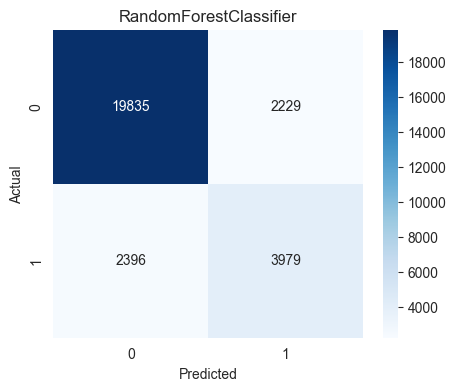

{'Accuracy': 0.8373712155842329,
 'Precision': 0.6409471649484536,
 'Recall': 0.6241568627450981,
 'F1': 0.6324405944528332,
 'ROC': 0.868377962860271}

In [60]:
rf_selected_result = evaluate_model(
    rf_selected,
    X_test_selected,
    y_test
)

rf_selected_result

In [61]:
comparison.loc["Random Forest Selected"] = rf_selected_result

comparison

,Accuracy,Precision,Recall,F1,ROC
Logistic Regression,0.785014,0.513707,0.767216,0.615375,0.858415
Random Forest,0.850909,0.710927,0.564392,0.629241,0.878655
XGBoost,0.847568,0.740113,0.493176,0.591923,0.867977
Random Forest Tuned,0.838321,0.644542,0.621490,0.632806,0.869283
Random Forest Selected,0.837371,0.640947,0.624157,0.632441,0.868378
